# Entrenamiento ML

Objetivo: encontrar el modelo de clasificación supervisada que mejor detecte Objetos Potencialmente Peligrosos (PHA) usando las variables preprocesadas en la etapa anterior.

Se entrenan y comparan múltiples clasificadores bajo validación cruzada estratificada, usando F1-score de la clase PHA como criterio de selección. Se evalúan dos experimentos:

- **Modelo A** (`trabajo_preprocesado_moid.pickle`): incluye `moid`. Máximo poder predictivo.
- **Modelo B** (`trabajo_preprocesado.pickle`): excluye `moid`. Variables físicas puras, sin el criterio que define la etiqueta target.

## 1. Importar paquetes

Se importan todas las dependencias del notebook: manipulación de datos, visualización, serialización de modelos, métricas de evaluación y los tres algoritmos de clasificación.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_curve, average_precision_score,
    classification_report
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## 2. Carga de datos

Se cargan los dos datasets generados en la etapa de preprocesamiento. Ambos tienen las mismas transformaciones aplicadas (homogeneización, encoding, escalado, eliminación de variables redundantes); la única diferencia es la presencia o ausencia de `moid`.

In [2]:
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'README.md').exists():
    repo_root = repo_root.parent

if not (repo_root / 'README.md').exists():
    raise FileNotFoundError('No se encontro la raiz del repositorio (README.md).')

# Modelo A: con moid
ruta_moid = repo_root / '02_Datos' / '03_Trabajo' / 'trabajo_preprocesado_moid.pickle'
df_moid = pd.read_pickle(ruta_moid)

# Modelo B: sin moid
ruta_sin_moid = repo_root / '02_Datos' / '03_Trabajo' / 'trabajo_preprocesado.pickle'
df = pd.read_pickle(ruta_sin_moid)

print(f'Modelo A (con moid):  {df_moid.shape}')
print(f'Modelo B (sin moid):  {df.shape}')
print(f'\nColumnas Modelo A: {df_moid.columns.tolist()}')
print(f'\nColumnas Modelo B: {df.columns.tolist()}')

Modelo A (con moid):  (88292, 28)
Modelo B (sin moid):  (88292, 27)

Columnas Modelo A: ['pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'tp', 'tp_cal', 'moid', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']

Columnas Modelo B: ['pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'tp', 'tp_cal', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']


## 3. Experimento A — Modelo con `moid`

Se trabaja con `df_moid` (88.292 filas). `moid` se incluye como feature. Este experimento puede producir métricas infladas dado que `moid < 0.05 UA` forma parte de la definición formal de PHA — los resultados del Experimento B (sin `moid`) son el punto de referencia para evaluar el poder predictivo real de las variables físicas.

### 3.1 Separación de features y target

Se separa `pha` del resto de features. La separación se aplica sobre el dataset completo de trabajo — los folds de validación cruzada se generan a partir de aquí, sin dividir manualmente en train/test previo.

In [3]:
X_moid = df_moid.drop(columns=['pha'])
y_moid = df_moid['pha']

print(f'Features (X): {X_moid.shape}')
print(f'Target  (y): {y_moid.shape}')
print(f'\nDistribución de clases:')
print(y_moid.value_counts())
print(f'\nProporción PHA: {y_moid.mean():.4f} ({y_moid.sum()} positivos de {len(y_moid)} total)')

Features (X): (88292, 27)
Target  (y): (88292,)

Distribución de clases:
pha
0    88185
1      107
Name: count, dtype: int64

Proporción PHA: 0.0012 (107 positivos de 88292 total)


### 3.2 Validación cruzada estratificada

Se usa `StratifiedKFold` con 5 folds para garantizar que cada fold mantiene la proporción de PHA (~2%). Un `KFold` estándar podría generar folds sin ningún ejemplo positivo, produciendo métricas inútiles o errores en el cálculo de F1.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Verificar que cada fold preserva la proporción de PHA
print(f'{"Fold":<6} {"Train PHA%":<12} {"Val PHA%":<12} {"Train n":<10} {"Val n":<10}')
print('-' * 50)
for fold, (train_idx, val_idx) in enumerate(cv.split(X_moid, y_moid), 1):
    train_pha = y_moid.iloc[train_idx].mean() * 100
    val_pha   = y_moid.iloc[val_idx].mean() * 100
    print(f'{fold:<6} {train_pha:<12.2f} {val_pha:<12.2f} {len(train_idx):<10} {len(val_idx):<10}')

Fold   Train PHA%   Val PHA%     Train n    Val n     
--------------------------------------------------
1      0.12         0.12         70633      17659     
2      0.12         0.12         70633      17659     
3      0.12         0.12         70634      17658     
4      0.12         0.12         70634      17658     
5      0.12         0.12         70634      17658     


### 3.3 Instanciación de modelos

Se instancian tres clasificadores con sus respectivas estrategias de balance de clases:

- **Logistic Regression** y **Random Forest**: `class_weight='balanced'` — sklearn ajusta internamente el peso de cada clase en proporción inversa a su frecuencia.
- **XGBoost**: `scale_pos_weight` — equivalente a `class_weight='balanced'`, calculado como la razón entre ejemplos negativos y positivos.

In [6]:
# Ratio para scale_pos_weight de XGBoost: negativos / positivos
neg = (y_moid == 0).sum()
pos = (y_moid == 1).sum()
spw = neg / pos
print(f"Negativos: {neg} | Positivos: {pos} | scale_pos_weight: {spw:.2f}")

logreg = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

rfc = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    scale_pos_weight=spw,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

modelos = {"logreg": logreg, "rfc": rfc, "xgb": xgb}
print("Modelos instanciados:", list(modelos.keys()))

Negativos: 88185 | Positivos: 107 | scale_pos_weight: 824.16
Modelos instanciados: ['logreg', 'rfc', 'xgb']


### 3.4 Grillas de hiperparámetros

Espacio de búsqueda de los tres modelos. Las grillas de LogReg y RF se recorren exhaustivamente con `GridSearchCV`. La de XGBoost se muestrea con `RandomizedSearchCV` dado su mayor espacio combinatorio.

In [7]:
# Logistic Regression -- 5 x 2 = 10 combinaciones x 5 folds = 50 fits
param_grid_logreg = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "solver":  ["lbfgs", "saga"],
    "penalty": ["l2"]
}

# Random Forest -- 2 x 3 x 2 x 2 = 24 combinaciones x 5 folds = 120 fits
param_grid_rfc = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2]
}

# XGBoost -- espacio amplio, se muestrean 20 combinaciones x 5 folds = 100 fits
param_dist_xgb = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [3, 4, 5, 6, 7],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

print(f"LogReg  -- combinaciones: {5*2}")
print(f"RF      -- combinaciones: {2*3*2*2}")
print(f"XGBoost -- espacio total: {4*5*4*3*3*3} | muestreados: 20")

LogReg  -- combinaciones: 10
RF      -- combinaciones: 24
XGBoost -- espacio total: 2160 | muestreados: 20


### 3.5 Instanciación de búsquedas

Criterio de optimización: `scoring='f1'` apunta a la clase positiva (PHA = 1). Cada buscador usa el mismo `cv` estratificado definido en 3.2.

In [8]:
gs_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_logreg,
    scoring="f1",
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1
)
print("GridSearchCV -- Logistic Regression instanciado")

GridSearchCV -- Logistic Regression instanciado


In [9]:
gs_rfc = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid_rfc,
    scoring="f1",
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1
)
print("GridSearchCV -- Random Forest instanciado")

GridSearchCV -- Random Forest instanciado


In [10]:
rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="f1",
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
print("RandomizedSearchCV -- XGBoost instanciado")

RandomizedSearchCV -- XGBoost instanciado


### 3.6 Entrenamiento y mejores configuraciones

Cada celda ejecuta el ajuste de forma independiente, registra el tiempo y muestra los mejores hiperparámetros junto con el F1-score obtenido en validación cruzada.

In [11]:
t0 = time.time()
gs_logreg.fit(X_moid, y_moid)
t_logreg = time.time() - t0

print(f"Tiempo de entrenamiento : {t_logreg:.1f}s")
print(f"Mejores hiperparametros : {gs_logreg.best_params_}")
print(f"Mejor F1 (CV)           : {gs_logreg.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Tiempo de entrenamiento : 201.7s
Mejores hiperparametros : {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor F1 (CV)           : 0.7149


In [12]:
t0 = time.time()
gs_rfc.fit(X_moid, y_moid)
t_rfc = time.time() - t0

print(f"Tiempo de entrenamiento : {t_rfc:.1f}s")
print(f"Mejores hiperparametros : {gs_rfc.best_params_}")
print(f"Mejor F1 (CV)           : {gs_rfc.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tiempo de entrenamiento : 244.3s
Mejores hiperparametros : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1 (CV)           : 0.9953


In [13]:
t0 = time.time()
rs_xgb.fit(X_moid, y_moid)
t_xgb = time.time() - t0

print(f"Tiempo de entrenamiento : {t_xgb:.1f}s")
print(f"Mejores hiperparametros : {rs_xgb.best_params_}")
print(f"Mejor F1 (CV)           : {rs_xgb.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tiempo de entrenamiento : 68.6s
Mejores hiperparametros : {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Mejor F1 (CV)           : 0.6290


### 3.7 Comparación de modelos

Se instancian los tres modelos con la mejor configuración encontrada en la búsqueda de hiperparámetros. 
La evaluación se realiza con `cross_validate` sobre los 5 folds estratificados, midiendo F1, AUC-ROC y Average Precision (área bajo la curva Precision-Recall).

In [14]:
best_logreg = LogisticRegression(
    **gs_logreg.best_params_,
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

best_rfc = RandomForestClassifier(
    **gs_rfc.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_xgb = XGBClassifier(
    **rs_xgb.best_params_,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

mejores_modelos = {
    'logreg': best_logreg,
    'rfc':    best_rfc,
    'xgb':    best_xgb,
}

#### Evaluación cruzada por modelo

| Métrica | Razón de uso |
|---------|-------------|
| **F1 (clase PHA)** | Criterio principal — balance entre precisión y recall en clase minoritaria |
| **AUC-ROC** | Capacidad discriminante global |
| **Average Precision** | Área bajo curva Precision-Recall; más informativa que AUC-ROC con desbalance extremo |

In [15]:
scoring = {
    'f1':                'f1',
    'roc_auc':           'roc_auc',
    'average_precision': 'average_precision',
}

resultados_cv = {}

for nombre, modelo in mejores_modelos.items():
    t0 = time.time()
    cv_res = cross_validate(modelo, X_moid, y_moid, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0
    resultados_cv[nombre] = {
        'F1':                cv_res['test_f1'].mean(),
        'F1_std':            cv_res['test_f1'].std(),
        'AUC-ROC':           cv_res['test_roc_auc'].mean(),
        'AUC-ROC_std':       cv_res['test_roc_auc'].std(),
        'Avg Precision':     cv_res['test_average_precision'].mean(),
        'Avg Precision_std': cv_res['test_average_precision'].std(),
        'Tiempo (s)':        round(elapsed, 1),
    }
    print(f'{nombre:<8} F1={resultados_cv[nombre]["F1"]:.4f}  '
          f'AUC={resultados_cv[nombre]["AUC-ROC"]:.4f}  '
          f'AP={resultados_cv[nombre]["Avg Precision"]:.4f}  '
          f'({elapsed:.1f}s)')

logreg   F1=0.7149  AUC=0.9998  AP=0.8093  (6.1s)
rfc      F1=0.9953  AUC=1.0000  AP=0.9897  (14.6s)
xgb      F1=0.6290  AUC=0.9951  AP=0.6741  (8.3s)


In [16]:
df_comparacion = pd.DataFrame(resultados_cv).T[['F1','F1_std','AUC-ROC','AUC-ROC_std','Avg Precision','Avg Precision_std','Tiempo (s)']]
df_comparacion.index.name = 'Modelo'
df_comparacion = df_comparacion.round(4)
df_comparacion

,F1,F1_std,AUC-ROC,AUC-ROC_std,Avg Precision,Avg Precision_std,Tiempo (s)
Modelo,,,,,,,
logreg,0.7149,0.0554,0.9998,0.0001,0.8093,0.0734,6.1
rfc,0.9953,0.0093,1.0000,0.0000,0.9897,0.0206,14.6
xgb,0.6290,0.0748,0.9951,0.0089,0.6741,0.0625,8.3


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Github\\Asteroid_Classification\\05_Resultados\\exp_a_comparacion_modelos.png'

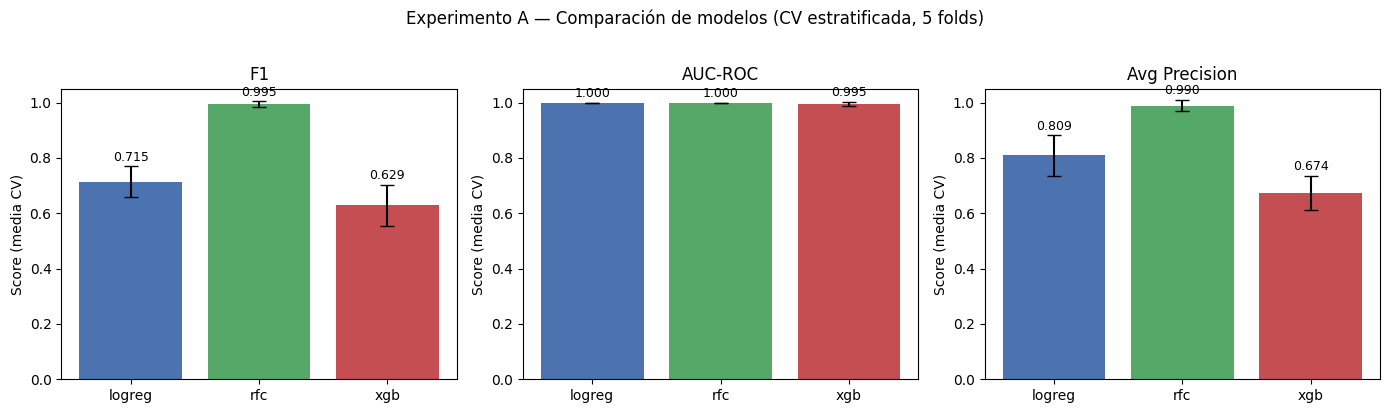

In [17]:
resultados_dir = repo_root / '05_Resultados'
resultados_dir.mkdir(parents=True, exist_ok=True)

metricas_plot = ['F1', 'AUC-ROC', 'Avg Precision']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metrica in zip(axes, metricas_plot):
    std_col = metrica + '_std'
    valores = df_comparacion[metrica]
    errores = df_comparacion[std_col]
    ax.bar(df_comparacion.index, valores, yerr=errores, capsize=5,
           color=['#4C72B0','#55A868','#C44E52'])
    ax.set_title(metrica)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score (media CV)')
    for i, v in enumerate(valores):
        ax.text(i, v + errores.iloc[i] + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Experimento A — Comparación de modelos (CV estratificada, 5 folds)', y=1.02)
plt.tight_layout()
plt.savefig(resultados_dir / 'exp_a_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

#### Selección del mejor modelo — Experimento A

Se elige el modelo con mayor **F1** promedio en validación cruzada. 
En caso de empate, se desempata por **Average Precision**.

In [18]:
mejor_nombre_a = df_comparacion['F1'].idxmax()
mejor_modelo_a = mejores_modelos[mejor_nombre_a]
mejor_fila_a   = df_comparacion.loc[mejor_nombre_a]

print('=== Mejor modelo — Experimento A ===')
print(f'  Algoritmo       : {mejor_nombre_a}')
print(f'  F1              : {mejor_fila_a["F1"]:.4f} ± {mejor_fila_a["F1_std"]:.4f}')
print(f'  AUC-ROC         : {mejor_fila_a["AUC-ROC"]:.4f} ± {mejor_fila_a["AUC-ROC_std"]:.4f}')
print(f'  Avg Precision   : {mejor_fila_a["Avg Precision"]:.4f} ± {mejor_fila_a["Avg Precision_std"]:.4f}')
print()
print('Hiperparametros optimos:')
if mejor_nombre_a == 'logreg':
    print(f'  {gs_logreg.best_params_}')
elif mejor_nombre_a == 'rfc':
    print(f'  {gs_rfc.best_params_}')
else:
    print(f'  {rs_xgb.best_params_}')

=== Mejor modelo — Experimento A ===
  Algoritmo       : rfc
  F1              : 0.9953 ± 0.0093
  AUC-ROC         : 1.0000 ± 0.0000
  Avg Precision   : 0.9897 ± 0.0206

Hiperparametros optimos:
  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
modelos_dir = repo_root / '04_Modelos'
modelos_dir.mkdir(parents=True, exist_ok=True)

experimento_a = 'A'
version_a     = 'v1'
ruta_modelo_a = modelos_dir / f'{mejor_nombre_a}_pha_{experimento_a}_{version_a}_pipeline.joblib'

mejor_modelo_a.fit(X_moid, y_moid)
joblib.dump(mejor_modelo_a, ruta_modelo_a)

print(f'Modelo guardado: {ruta_modelo_a.name}')
print(f'Ruta            : {ruta_modelo_a}')

## 4. Experimento B — Modelo sin `moid`

Se trabaja con `df_nomoid` (sin la variable `moid`). El objetivo es evaluar si un modelo basado únicamente en variables físicas orbitales puede clasificar PHA con métricas comparables al Experimento A. La estructura del experimento es idéntica: mismos algoritmos, mismas grillas, mismo criterio de optimización.

### 4.1 Separación de features y target

Se separa `pha` del resto de features. El dataset no contiene `moid` ni ninguna variable derivada de ella.

In [ ]:
X_nomoid = df_nomoid.drop(columns=['pha'])
y_nomoid = df_nomoid['pha']

print(f'Features : {X_nomoid.shape[1]} columnas')
print(f'Registros: {X_nomoid.shape[0]:,}')
print(f'PHA (1)  : {y_nomoid.sum():,} ({y_nomoid.mean()*100:.2f}%)')
print(f'No PHA(0): {(y_nomoid==0).sum():,} ({(y_nomoid==0).mean()*100:.2f}%)')
print(f'\nColumnas: {list(X_nomoid.columns)}')

### 4.2 Validación cruzada estratificada

Se reutiliza el mismo objeto `cv` (`StratifiedKFold`, n=5, random_state=42) definido en el Experimento A. Se verifica que la proporción de PHA se mantenga estable en cada fold.

In [ ]:
print(f'{'Fold':<6} {'%PHA train':<12} {'%PHA val':<12} {'n_train':<10} {'n_val'}')
print('-' * 50)
for fold, (train_idx, val_idx) in enumerate(cv.split(X_nomoid, y_nomoid), 1):
    train_pha = y_nomoid.iloc[train_idx].mean() * 100
    val_pha   = y_nomoid.iloc[val_idx].mean() * 100
    print(f'{fold:<6} {train_pha:<12.2f} {val_pha:<12.2f} {len(train_idx):<10,} {len(val_idx):,}')

### 4.3 Instanciación de modelos

Se instancian los mismos tres clasificadores con la misma configuración de balanceo y reproducibilidad. El `scale_pos_weight` se recalcula sobre `y_nomoid` (el ratio es prácticamente idéntico al de Experimento A).

In [ ]:
neg_b, pos_b = (y_nomoid == 0).sum(), (y_nomoid == 1).sum()
spw_b = neg_b / pos_b

logreg_b = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rfc_b    = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
xgb_b    = XGBClassifier(scale_pos_weight=spw_b, random_state=42, eval_metric='logloss', n_jobs=-1)

modelos_b = {'logreg': logreg_b, 'rfc': rfc_b, 'xgb': xgb_b}
print(f'scale_pos_weight Exp B: {spw_b:.2f}')

### 4.4 Grillas de hiperparámetros

Se reutilizan las mismas grillas del Experimento A para mantener comparabilidad entre experimentos.

In [ ]:
# Mismas grillas que Experimento A
param_grid_logreg_b = param_grid_logreg
param_grid_rfc_b    = param_grid_rfc
param_dist_xgb_b    = param_dist_xgb

### 4.5 Instanciación de búsquedas

Misma configuración que Experimento A: `GridSearchCV` para LogReg y RF, `RandomizedSearchCV` (n_iter=20) para XGBoost. Criterio de optimización: `scoring='f1'`.

In [ ]:
gs_logreg_b = GridSearchCV(
    estimator=logreg_b,
    param_grid=param_grid_logreg_b,
    scoring='f1',
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1
)

In [ ]:
gs_rfc_b = GridSearchCV(
    estimator=rfc_b,
    param_grid=param_grid_rfc_b,
    scoring='f1',
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1
)

In [ ]:
rs_xgb_b = RandomizedSearchCV(
    estimator=xgb_b,
    param_distributions=param_dist_xgb_b,
    n_iter=20,
    scoring='f1',
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

### 4.6 Entrenamiento y mejores configuraciones

Cada celda ejecuta el ajuste completo sobre `X_nomoid` / `y_nomoid` e imprime los mejores hiperparámetros y el F1 de CV obtenido.

In [ ]:
t0 = time.time()
gs_logreg_b.fit(X_nomoid, y_nomoid)
t_logreg_b = time.time() - t0
print(f'Tiempo de entrenamiento : {t_logreg_b:.1f}s')
print(f'Mejores hiperparametros : {gs_logreg_b.best_params_}')
print(f'Mejor F1 (CV)           : {gs_logreg_b.best_score_:.4f}')

In [ ]:
t0 = time.time()
gs_rfc_b.fit(X_nomoid, y_nomoid)
t_rfc_b = time.time() - t0
print(f'Tiempo de entrenamiento : {t_rfc_b:.1f}s')
print(f'Mejores hiperparametros : {gs_rfc_b.best_params_}')
print(f'Mejor F1 (CV)           : {gs_rfc_b.best_score_:.4f}')

In [ ]:
t0 = time.time()
rs_xgb_b.fit(X_nomoid, y_nomoid)
t_xgb_b = time.time() - t0
print(f'Tiempo de entrenamiento : {t_xgb_b:.1f}s')
print(f'Mejores hiperparametros : {rs_xgb_b.best_params_}')
print(f'Mejor F1 (CV)           : {rs_xgb_b.best_score_:.4f}')

### 4.7 Comparación de modelos

Se instancian los tres modelos con la mejor configuración encontrada y se evalúan con `cross_validate` sobre los 5 folds estratificados.

In [ ]:
best_logreg_b = LogisticRegression(
    **gs_logreg_b.best_params_,
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

best_rfc_b = RandomForestClassifier(
    **gs_rfc_b.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_xgb_b = XGBClassifier(
    **rs_xgb_b.best_params_,
    scale_pos_weight=spw_b,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

mejores_modelos_b = {
    'logreg': best_logreg_b,
    'rfc':    best_rfc_b,
    'xgb':    best_xgb_b,
}

#### Evaluación cruzada por modelo

Se aplican las mismas tres métricas que en el Experimento A:

| Métrica | Razón de uso |
|---------|-------------|
| **F1 (clase PHA)** | Criterio principal — balance entre precisión y recall en clase minoritaria |
| **AUC-ROC** | Capacidad discriminante global |
| **Average Precision** | Área bajo curva Precision-Recall; más informativa que AUC-ROC con desbalance extremo |

In [ ]:
resultados_cv_b = {}

for nombre, modelo in mejores_modelos_b.items():
    t0 = time.time()
    cv_res = cross_validate(modelo, X_nomoid, y_nomoid, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0
    resultados_cv_b[nombre] = {
        'F1':                cv_res['test_f1'].mean(),
        'F1_std':            cv_res['test_f1'].std(),
        'AUC-ROC':           cv_res['test_roc_auc'].mean(),
        'AUC-ROC_std':       cv_res['test_roc_auc'].std(),
        'Avg Precision':     cv_res['test_average_precision'].mean(),
        'Avg Precision_std': cv_res['test_average_precision'].std(),
        'Tiempo (s)':        round(elapsed, 1),
    }
    print(f'{nombre:<8} F1={resultados_cv_b[nombre]["F1"]:.4f}  '
          f'AUC={resultados_cv_b[nombre]["AUC-ROC"]:.4f}  '
          f'AP={resultados_cv_b[nombre]["Avg Precision"]:.4f}  '
          f'({elapsed:.1f}s)')

In [ ]:
df_comparacion_b = pd.DataFrame(resultados_cv_b).T[['F1','F1_std','AUC-ROC','AUC-ROC_std','Avg Precision','Avg Precision_std','Tiempo (s)']]
df_comparacion_b.index.name = 'Modelo'
df_comparacion_b = df_comparacion_b.round(4)
df_comparacion_b

In [ ]:
resultados_dir.mkdir(parents=True, exist_ok=True)

metricas_plot = ['F1', 'AUC-ROC', 'Avg Precision']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metrica in zip(axes, metricas_plot):
    std_col = metrica + '_std'
    valores = df_comparacion_b[metrica]
    errores = df_comparacion_b[std_col]
    ax.bar(df_comparacion_b.index, valores, yerr=errores, capsize=5,
           color=['#4C72B0','#55A868','#C44E52'])
    ax.set_title(metrica)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score (media CV)')
    for i, v in enumerate(valores):
        ax.text(i, v + errores.iloc[i] + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Experimento B — Comparación de modelos (CV estratificada, 5 folds)', y=1.02)
plt.tight_layout()
plt.savefig(resultados_dir / 'exp_b_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

#### Selección del mejor modelo — Experimento B

Se elige el modelo con mayor **F1** promedio. En caso de empate, se desempata por **Average Precision**.

In [ ]:
mejor_nombre_b = df_comparacion_b['F1'].idxmax()
mejor_modelo_b = mejores_modelos_b[mejor_nombre_b]
mejor_fila_b   = df_comparacion_b.loc[mejor_nombre_b]

print('=== Mejor modelo — Experimento B ===')
print(f'  Algoritmo       : {mejor_nombre_b}')
print(f'  F1              : {mejor_fila_b["F1"]:.4f} ± {mejor_fila_b["F1_std"]:.4f}')
print(f'  AUC-ROC         : {mejor_fila_b["AUC-ROC"]:.4f} ± {mejor_fila_b["AUC-ROC_std"]:.4f}')
print(f'  Avg Precision   : {mejor_fila_b["Avg Precision"]:.4f} ± {mejor_fila_b["Avg Precision_std"]:.4f}')
print()
print('Hiperparametros optimos:')
if mejor_nombre_b == 'logreg':
    print(f'  {gs_logreg_b.best_params_}')
elif mejor_nombre_b == 'rfc':
    print(f'  {gs_rfc_b.best_params_}')
else:
    print(f'  {rs_xgb_b.best_params_}')

In [ ]:
modelos_dir.mkdir(parents=True, exist_ok=True)

experimento_b = 'B'
version_b     = 'v1'
ruta_modelo_b = modelos_dir / f'{mejor_nombre_b}_pha_{experimento_b}_{version_b}_pipeline.joblib'

mejor_modelo_b.fit(X_nomoid, y_nomoid)
joblib.dump(mejor_modelo_b, ruta_modelo_b)

print(f'Modelo guardado: {ruta_modelo_b.name}')
print(f'Ruta            : {ruta_modelo_b}')